In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize

daily_returns = pd.read_csv("../data/processed/daily_returns.csv", index_col=0, parse_dates=True)

tickers = daily_returns.columns.tolist()
n_assets = len(tickers)

daily_returns.head()

,SPY,QQQ,IWM,TLT,GLD,VNQ,EFA
Date,,,,,,,
2015-01-05,-0.018060,-0.014676,-0.013369,0.015708,0.015077,0.005473,-0.023605
2015-01-06,-0.009419,-0.013415,-0.017300,0.018017,0.011399,0.009919,-0.011327
2015-01-07,0.012461,0.012897,0.012315,-0.001975,-0.005891,0.015331,0.011115
2015-01-08,0.017745,0.019149,0.016962,-0.013243,-0.004209,0.003775,0.013530
2015-01-09,-0.008014,-0.006586,-0.009603,0.010953,0.011385,0.000470,-0.004839


In [2]:
trading_days = 252
risk_free_rate = 0.02

mean_returns = daily_returns.mean() * trading_days
cov_matrix = daily_returns.cov() * trading_days

In [3]:
def portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate=0.02):
    portfolio_return = np.dot(weights, mean_returns)
    portfolio_volatility = np.sqrt(np.dot(weights.T, np.dot(cov_matrix, weights)))
    sharpe_ratio = (portfolio_return - risk_free_rate) / portfolio_volatility
    return portfolio_return, portfolio_volatility, sharpe_ratio

In [4]:
equal_weights = np.array([1 / n_assets] * n_assets)

equal_return, equal_vol, equal_sharpe = portfolio_performance(
    equal_weights, mean_returns, cov_matrix, risk_free_rate
)

equal_weights

array([0.14285714, 0.14285714, 0.14285714, 0.14285714, 0.14285714,
       0.14285714, 0.14285714])

In [5]:
def portfolio_volatility(weights, mean_returns, cov_matrix):
    return portfolio_performance(weights, mean_returns, cov_matrix)[1]

constraints = {"type": "eq", "fun": lambda weights: np.sum(weights) - 1}
bounds = tuple((0, 1) for _ in range(n_assets))
initial_weights = np.array([1 / n_assets] * n_assets)

min_var_result = minimize(
    portfolio_volatility,
    initial_weights,
    args=(mean_returns, cov_matrix),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

min_var_weights = min_var_result.x
min_var_weights

array([2.44681057e-01, 0.00000000e+00, 0.00000000e+00, 3.89144424e-01,
       2.65184604e-01, 2.11419424e-18, 1.00989915e-01])

In [6]:
def negative_sharpe(weights, mean_returns, cov_matrix, risk_free_rate):
    return -portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)[2]

max_sharpe_result = minimize(
    negative_sharpe,
    initial_weights,
    args=(mean_returns, cov_matrix, risk_free_rate),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

max_sharpe_weights = max_sharpe_result.x
max_sharpe_weights

array([0.00000000e+00, 4.20588431e-01, 5.28662496e-17, 0.00000000e+00,
       5.79411569e-01, 0.00000000e+00, 4.86677998e-17])

In [7]:
def risk_contribution(weights, cov_matrix):
    portfolio_var = np.dot(weights.T, np.dot(cov_matrix, weights))
    marginal_contrib = np.dot(cov_matrix, weights)
    risk_contrib = weights * marginal_contrib / portfolio_var
    return risk_contrib

def risk_parity_objective(weights, cov_matrix):
    rc = risk_contribution(weights, cov_matrix)
    target_rc = np.array([1 / len(weights)] * len(weights))
    return np.sum((rc - target_rc) ** 2)

risk_parity_result = minimize(
    risk_parity_objective,
    initial_weights,
    args=(cov_matrix,),
    method="SLSQP",
    bounds=bounds,
    constraints=constraints
)

risk_parity_weights = risk_parity_result.x
risk_parity_weights

array([0.11008405, 0.09397042, 0.09087763, 0.27840849, 0.21216755,
       0.09791473, 0.11657714])

In [8]:
weights_table = pd.DataFrame({
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights,
    "Risk Parity": risk_parity_weights
}, index=tickers)

weights_table

,Equal Weight,Minimum Variance,Maximum Sharpe,Risk Parity
SPY,0.142857,2.446811e-01,0.000000e+00,0.110084
QQQ,0.142857,0.000000e+00,4.205884e-01,0.093970
IWM,0.142857,0.000000e+00,5.286625e-17,0.090878
TLT,0.142857,3.891444e-01,0.000000e+00,0.278408
GLD,0.142857,2.651846e-01,5.794116e-01,0.212168
VNQ,0.142857,2.114194e-18,0.000000e+00,0.097915
EFA,0.142857,1.009899e-01,4.866780e-17,0.116577


In [9]:
weights_table.to_csv("../data/processed/static_portfolio_weights.csv")

In [12]:
strategies = {
    "Equal Weight": equal_weights,
    "Minimum Variance": min_var_weights,
    "Maximum Sharpe": max_sharpe_weights,
    "Risk Parity": risk_parity_weights
}

performance = {}

for name, weights in strategies.items():
    ret, vol, sharpe = portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)
    performance[name] = {
        "Annualized Return": ret,
        "Annualized Volatility": vol,
        "Sharpe Ratio": sharpe
    }

performance_table = pd.DataFrame(performance).T
performance_table

performance_table.to_csv("../data/processed/static_portfolio_performance.csv")

,Annualized Return,Annualized Volatility,Sharpe Ratio
Equal Weight,0.084412,0.132295,0.486879
Minimum Variance,0.060412,0.093828,0.430700
Maximum Sharpe,0.150781,0.129101,1.013011
Risk Parity,0.069089,0.106072,0.462788


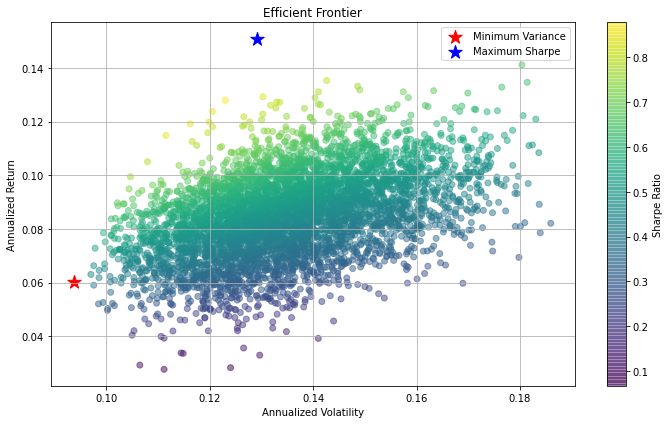

In [13]:
num_portfolios = 5000
results = []

for _ in range(num_portfolios):
    weights = np.random.random(n_assets)
    weights = weights / np.sum(weights)
    ret, vol, sharpe = portfolio_performance(weights, mean_returns, cov_matrix, risk_free_rate)
    results.append([ret, vol, sharpe])

results = pd.DataFrame(results, columns=["Return", "Volatility", "Sharpe"])

plt.figure(figsize=(10, 6))

plt.scatter(
    results["Volatility"].to_numpy(),
    results["Return"].to_numpy(),
    c=results["Sharpe"].to_numpy(),
    cmap="viridis",
    alpha=0.5
)

plt.colorbar(label="Sharpe Ratio")

plt.scatter(
    performance_table.loc["Minimum Variance", "Annualized Volatility"],
    performance_table.loc["Minimum Variance", "Annualized Return"],
    marker="*",
    color="red",
    s=200,
    label="Minimum Variance"
)

plt.scatter(
    performance_table.loc["Maximum Sharpe", "Annualized Volatility"],
    performance_table.loc["Maximum Sharpe", "Annualized Return"],
    marker="*",
    color="blue",
    s=200,
    label="Maximum Sharpe"
)

plt.title("Efficient Frontier")
plt.xlabel("Annualized Volatility")
plt.ylabel("Annualized Return")
plt.legend()
plt.grid(True)
plt.tight_layout()

plt.savefig("../figures/effective_frontier.png", dpi=300)
plt.show()

## Key Observations

The static optimization results show clear differences across portfolio construction methods. The minimum variance portfolio allocates more weight to defensive or diversifying assets such as TLT and GLD, resulting in the lowest annualized volatility. The maximum Sharpe portfolio is more concentrated in assets with stronger historical risk-adjusted returns, especially GLD and QQQ. The risk parity portfolio produces a more balanced allocation by distributing risk contributions across assets rather than simply equalizing capital weights.

These static results are useful for understanding the behavior of different optimization methods, but they should not be interpreted as out-of-sample investment performance because the weights are estimated using the full sample period. A rolling-window backtest is needed in the next step to avoid look-ahead bias.